# Przygotowanie środowiska

In [1]:
from pathlib import Path

# aktualny katalog roboczy notebooka
current_dir = Path.cwd()

scene = "room_0"

data_path = current_dir.parent / "sound-spaces/data/scene_datasets/replica"

scene_config = data_path / scene / "habitat/replica_stage.stage_config.json"

print("Aktualny katalog:", current_dir)
print("Dataset:", data_path)
print("Scene config:", scene_config)
print("Istnieje:", scene_config.exists())

Aktualny katalog: /home/d4krzyk/Dokumenty/MasterWorkVE/my-operations
Dataset: /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica
Scene config: /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_0/habitat/replica_stage.stage_config.json
Istnieje: True


In [2]:
import habitat_sim

print("1. import OK")

cfg = habitat_sim.SimulatorConfiguration()

print("2. cfg OK")

cfg.scene_dataset_config_file = (
    str(data_path) + "/replica.scene_dataset_config.json"
)
cfg.scene_id = scene
# habitat_sim.Simulator overrides create_renderer based on whether any agent
# has sensors (see simulator.py:_sanitize_config) - setting it directly here
# has no effect. Without a sensor, the renderer stays off and PTex (Replica)
# stage loading aborts in PTexMeshData::getRenderingBuffer (the kernel crash
# seen below before this fix). A sensor is required even if RGB isn't used.
cfg.create_renderer = True
cfg.gpu_device_id = 0

print("3. config OK")

rgb_sensor_spec = habitat_sim.CameraSensorSpec()
rgb_sensor_spec.uuid = "color_sensor"
rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
rgb_sensor_spec.resolution = [128, 128]

agent_cfg = habitat_sim.agent.AgentConfiguration()
agent_cfg.sensor_specifications = [rgb_sensor_spec]

print("4. agent OK")

1. import OK
2. cfg OK
3. config OK
4. agent OK


/home/d4krzyk/miniforge3/envs/habitat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sim = habitat_sim.Simulator(
    habitat_sim.Configuration(cfg, [agent_cfg])
)

print("5. SIM OK")

5. SIM OK
[16:43:16:275872]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[16:43:16:276098]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[16:43:16:276158]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[16:43:16:276200]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[16:43:16:276236]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneW

[16:43:16:277852]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[16:43:16:278141]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/*_[0-9]/habitat/replica_stage.stage_config.json : /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/apartment_0/habitat/replica_stage.stage_config.json
[16:43:16:278360]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/*_[0-9]/habitat/replica_stage.stage_config.json : /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/apartment_1/habitat/replica_stage.stage_config.json
[16:43:16:278510]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob

etadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[16:43:16:277224]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[16:43:16:277253]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneWireframe_segments_32_halfLen_1.25) created and registered.
[16:43:16:277279]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (cubeSolid:cubeSolid) created and registered.
[16:43:16:277303]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (cubeWireframe:cubeWireframe) created and registered.
[16:43:16:277332]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (cylinderSolid:cylinderSolid_rings_1_seg

# Analiza architektury i danych

In [6]:
import pickle
import networkx as nx
import numpy as np

# Wczytanie grafu dla konkretnej sceny
with open(f'metadata/replica/{scene}/graph.pkl', 'rb') as f:
    graph = pickle.load(f)

# Wyciągnięcie pozycji XYZ wszystkich punktów
# location_id w Twoim DataFrame to indeks na tej liście
node_positions = [np.asarray(graph.nodes[n]['point'], dtype=float) for n in graph.nodes()]

# Przykład: lokalizacja o ID 4 z Twojego pliku .pkl
id = 50
target_xyz = node_positions[id]
print(f"Dla location_id={id}, fizyczne współrzędne to: {target_xyz}")

Dla location_id=50, fizyczne współrzędne to: [ 4.752906  -1.5491767 -1.913136 ]


In [9]:
import numpy as np
import pandas as pd
meta_points = pd.read_csv(f'metadata/replica/{scene}/points.txt', delimiter='\t')
print((meta_points.head(130)))

       0  -0.747094  -0.586864  0.003714
0      1  -0.747094  -0.086864  0.003714
1      2  -0.747094   0.413136  0.003714
2      3  -0.747094   0.913136  0.003714
3      4  -0.747094   1.413136  0.003714
4      5  -0.747094   1.913136  0.003714
..   ...        ...        ...       ...
125  126   6.252906   2.413136  0.003714
126  127   6.252906   2.913136  0.003714
127  128   6.752906  -1.086864  0.003714
128  129   6.752906  -0.586864  0.003714
129  130   6.752906  -0.086864  0.003714

[130 rows x 4 columns]


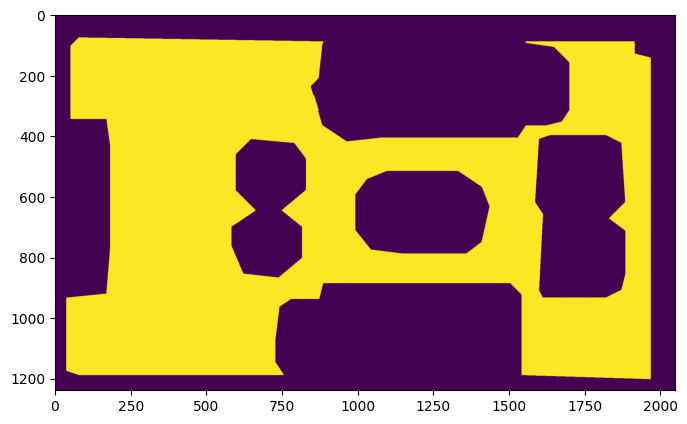

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import habitat_sim

# zakładam że sim już istnieje i navmesh jest załadowany

# 1. top-down render navmesh
bounds = sim.pathfinder.get_bounds()
min_b, max_b = bounds

meters_per_pixel = max(max_b[0] - min_b[0], max_b[2] - min_b[2]) / 2048.0
height = float(node_positions[0][1])

topdown = sim.pathfinder.get_topdown_view(meters_per_pixel, height)

plt.figure(figsize=(8, 8))
plt.imshow(topdown, origin="upper")
#print(min_b, max_b)

In [11]:
import pickle
import numpy as np

# 1) Przygotuj współrzędne punktów (spróbuj użyć zmiennej `points` jeśli istnieje)
points = np.array(node_positions)  # Zakładam, że node_positions to lista [ID, x, y, z]
ids = points[:, 0].astype(int)
coords = points[:, 1:4].astype(float)
order = np.argsort(ids)
coords_sorted = coords[order]

# 2) oblicz odległości między sąsiednimi punktami (ID i ID+1)
diffs = coords_sorted[1:] - coords_sorted[:-1]
dists = np.linalg.norm(diffs, axis=1)

# 3) wyświetl pierwsze 30 odległości oraz podstawowe statystyki
for idx, dist in enumerate(dists[:10]):
    print(f"id {idx} -> {idx+1}: {dist:.3f} m")

print()
print("Statystyki:")
print("  count:", len(dists))
print("  mean: {:.3f} m".format(dists.mean()))
print("  median: {:.3f} m".format(np.median(dists)))
print("  min: {:.3f} m".format(dists.min()))
print("  max: {:.3f} m".format(dists.max()))

id 0 -> 1: 3.500 m
id 1 -> 2: 0.500 m
id 2 -> 3: 0.500 m
id 3 -> 4: 0.500 m
id 4 -> 5: 0.500 m
id 5 -> 6: 0.500 m
id 6 -> 7: 0.500 m
id 7 -> 8: 3.000 m
id 8 -> 9: 0.500 m
id 9 -> 10: 3.000 m

Statystyki:
  count: 50
  mean: 1.230 m
  median: 0.750 m
  min: 0.000 m
  max: 3.500 m


In [12]:
import pickle
import pandas as pd

with open("../scenes_ve_metadata_locations/scene_observations_128.pkl", "rb") as f:
    observations = pickle.load(f)

observations.keys()

FileNotFoundError: [Errno 2] No such file or directory: '../scenes_ve_metadata_locations/scene_observations_128.pkl'

In [ ]:
observations[scene]

In [ ]:
# Lzejszy podglad RGB dla apartment_0 z filtrem orientation (0/90/180/270)
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


orientations = [0, 90, 180, 270]
state = {"idx": 0}
states = observations.get(scene, {})

def build_frames(orientation):
    frames = []
    for (loc, ori), obs in sorted(states.items(), key=lambda x: x[0][0]):
        if ori != orientation:
            continue
        rgb = obs.get("rgb")
        if rgb is None:
            continue
        frames.append((loc, rgb))
    return frames

out = widgets.Output()
btn_left = widgets.Button(description="Orientation -90")
btn_right = widgets.Button(description="Orientation +90")
play = widgets.Play(interval=200, value=0, min=0, max=0, step=1, description="Play")
slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Frame")
widgets.jslink((play, "value"), (slider, "value"))

def render_frame(frames, idx, orientation):
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.axis("off")
        loc, rgb = frames[idx]
        ax.imshow(rgb)
        ax.set_title(f"{scene} | location_id={loc} | orientation={orientation}", fontsize=10)
        display(fig)
        plt.close(fig)

def refresh(orientation):
    frames = build_frames(orientation)
    if not frames:
        raise ValueError(f"Brak klatek RGB dla orientation={orientation} w tej scenie.")
    prev_idx = min(slider.value, len(frames) - 1)
    slider.max = len(frames) - 1
    play.max = len(frames) - 1
    slider.value = prev_idx
    render_frame(frames, slider.value, orientation)

    def on_value_change(change):
        if change["name"] == "value":
            render_frame(frames, change["new"], orientation)

    slider.unobserve_all()
    slider.observe(on_value_change, names="value")

def change_orientation(delta):
    state["idx"] = (state["idx"] + delta) % len(orientations)
    refresh(orientations[state["idx"]])

btn_left.on_click(lambda _btn: change_orientation(-1))
btn_right.on_click(lambda _btn: change_orientation(1))

controls = widgets.HBox([btn_left, btn_right, play, slider])
display(controls)
display(out)
refresh(orientations[state["idx"]])

In [ ]:
rows = []

for scene_name, states in observations.items():
    for (loc, ori), obs in states.items():
        rows.append({
            "scene": scene_name,
            "location_id": loc,
            "orientation": ori,
            "has_rgb": obs["rgb"] is not None,
            "has_depth": obs["depth"] is not None
        })

df = pd.DataFrame(rows)

print(df[df["scene"] == scene].head(10))

observ_ids = df[df["scene"] == scene]['location_id'].unique()
print(observ_ids)
print(len(observ_ids))

# Rysowanie mapy dla danej sceny

In [ ]:
# Overlay graph nodes with location_id labels from observations
import matplotlib.pyplot as plt
import numpy as np

# Load graph if not already in memory
if "graph" not in globals():
    import pickle
    with open(f"../metadata/replica/{scene}/graph.pkl", "rb") as f:
        graph = pickle.load(f)

# Map node id -> (x, y, z) position
node_positions = {}
for n, data in graph.nodes(data=True):
    pos = None
    if isinstance(data, dict):
        pos = data.get("point")
    elif isinstance(data, (list, tuple)) and len(data) >= 3:
        pos = data[:3]
    if pos is not None:
        node_positions[int(n)] = np.asarray(pos, dtype=float)

if len(node_positions) == 0:
    raise ValueError("No node positions found in graph node attributes.")

# All nodes (background)
all_ids = sorted(node_positions.keys())
all_pts = np.vstack([node_positions[i] for i in all_ids])
all_px = (all_pts[:, 0] - min_b[0]) / meters_per_pixel
all_pz = (all_pts[:, 2] - min_b[2]) / meters_per_pixel

# Observed nodes (labeled)
observ_ids_in_graph = [i for i in observ_ids if i in node_positions]
if len(observ_ids_in_graph) > 0:
    obs_pts = np.vstack([node_positions[i] for i in observ_ids_in_graph])
    obs_px = (obs_pts[:, 0] - min_b[0]) / meters_per_pixel
    obs_pz = (obs_pts[:, 2] - min_b[2]) / meters_per_pixel
else:
    obs_px = np.array([])
    obs_pz = np.array([])

plt.figure(figsize=(16, 16), dpi=120)
plt.imshow(topdown, origin="upper", cmap="gray")
plt.scatter(all_px, all_pz, s=6, c="lightgray", alpha=0.5, label="all graph nodes")
plt.scatter(obs_px, obs_pz, s=18, c="red", alpha=0.9, label="observed location_id")

# Add location_id labels
for loc_id, x_px, z_px in zip(observ_ids_in_graph, obs_px, obs_pz):
    plt.text(x_px, z_px, str(loc_id), color="black", fontsize=12, ha="center", va="center")

plt.legend()
plt.title(f"Observed location_id on topdown: {scene}")
plt.show()
print(f"Total graph nodes: {len(all_ids)}, Observed location_id in graph: {len(observ_ids_in_graph)}")

# Porównanie punktów z metadanych do ilości obserwacji z wygnerowanych RIR

In [ ]:

print(f"Pobrano {len(all_pts)} lokalizacji dla tej sceny [{scene}].")

In [ ]:
print(df.groupby("scene")["location_id"].nunique())


# Skrypt dla wszystkich scen

In [ ]:
# Check counts: metadata nodes vs observation locations
def compare_counts(scene, observations):
    graph_path = f"../metadata/replica/{scene}/graph.pkl"
    if not os.path.exists(graph_path):
        return (scene, None, None, "missing graph")
    with open(graph_path, "rb") as f:
        graph = pickle.load(f)

    node_count = graph.number_of_nodes() if hasattr(graph, "number_of_nodes") else len(graph)
    obs_count = len({loc for (loc, _ori) in observations[scene].keys()})
    status = "OK" if node_count == obs_count else "DIFF"
    return (scene, node_count, obs_count, status)

results = [compare_counts(s, observations) for s in random_scenes]
for scene_name, node_count, obs_count, status in results:
    print(f"{scene_name}: nodes={node_count}, observations={obs_count} -> {status}")

In [ ]:
# Batch overlay for random scenes (same approach as apartment_0)
import random
import numpy as np
import matplotlib.pyplot as plt
import habitat_sim
import os
import pickle

def render_scene_with_labels(scene, observations, data_path="../data/scene_datasets/replica"):
    scene_config = os.path.join(data_path, scene, "habitat/replica_stage.stage_config.json")
    navmesh_path = os.path.join(data_path, scene, "habitat/mesh_semantic.navmesh")
    if not os.path.exists(scene_config):
        print(f"Skip {scene}: missing config {scene_config}")
        return False

    cfg = habitat_sim.SimulatorConfiguration()
    cfg.scene_id = scene_config
    # A sensor is required for create_renderer to actually take effect - see
    # the note in the earlier "Przygotowanie środowiska" cell. Without one,
    # this crashes the kernel on every PTex (Replica) scene.
    cfg.create_renderer = True
    cfg.enable_physics = False
    cfg.gpu_device_id = 0

    rgb_sensor_spec = habitat_sim.CameraSensorSpec()
    rgb_sensor_spec.uuid = "color_sensor"
    rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_sensor_spec.resolution = [128, 128]

    agent_cfg = habitat_sim.agent.AgentConfiguration()
    agent_cfg.sensor_specifications = [rgb_sensor_spec]

    sim_local = habitat_sim.Simulator(habitat_sim.Configuration(cfg, [agent_cfg]))
    try:
        if os.path.exists(navmesh_path):
            sim_local.pathfinder.load_nav_mesh(navmesh_path)
        if not sim_local.pathfinder.is_loaded:
            print(f"Skip {scene}: navmesh not loaded")
            return False

        bounds = sim_local.pathfinder.get_bounds()
        min_b, max_b = bounds
        meters_per_pixel = max(max_b[0] - min_b[0], max_b[2] - min_b[2]) / 1024.0

        graph_path = f"../metadata/replica/{scene}/graph.pkl"
        if not os.path.exists(graph_path):
            print(f"Skip {scene}: missing graph {graph_path}")
            return False
        with open(graph_path, "rb") as f:
            graph = pickle.load(f)

        node_positions = {}
        for n, data in graph.nodes(data=True):
            pos = None
            if isinstance(data, dict):
                pos = data.get("point")
            elif isinstance(data, (list, tuple)) and len(data) >= 3:
                pos = data[:3]
            if pos is not None:
                node_positions[int(n)] = np.asarray(pos, dtype=float)
        if len(node_positions) == 0:
            print(f"Skip {scene}: no node positions")
            return False

        height = float(np.mean([p[1] for p in node_positions.values()]))
        topdown = sim_local.pathfinder.get_topdown_view(meters_per_pixel, height)

        all_ids = sorted(node_positions.keys())
        all_pts = np.vstack([node_positions[i] for i in all_ids])
        all_px = (all_pts[:, 0] - min_b[0]) / meters_per_pixel
        all_pz = (all_pts[:, 2] - min_b[2]) / meters_per_pixel

        observ_ids = sorted({loc for (loc, _ori) in observations[scene].keys() if loc in node_positions})
        if len(observ_ids) > 0:
            obs_pts = np.vstack([node_positions[i] for i in observ_ids])
            obs_px = (obs_pts[:, 0] - min_b[0]) / meters_per_pixel
            obs_pz = (obs_pts[:, 2] - min_b[2]) / meters_per_pixel
        else:
            obs_px = np.array([])
            obs_pz = np.array([])

        plt.figure(figsize=(16, 16), dpi=120)
        plt.imshow(topdown, origin="upper", cmap="gray")
        plt.scatter(all_px, all_pz, s=6, c="lightgray", alpha=0.5, label="all graph nodes")
        plt.scatter(obs_px, obs_pz, s=18, c="red", alpha=0.9, label="observed location_id")
        for loc_id, x_px, z_px in zip(observ_ids, obs_px, obs_pz):
            plt.text(x_px, z_px, str(loc_id), color="black", fontsize=12, ha="center", va="center")
        plt.legend()
        plt.title(f"Observed location_id on topdown: {scene}")
        plt.show()
        return True
    finally:
        sim_local.close()

# Pick random 20 scenes and render
all_scenes = sorted(observations.keys())
sample_count = min(20, len(all_scenes))
random_scenes = random.sample(all_scenes, sample_count)
print("Random scenes:", random_scenes)

for scene_name in random_scenes:
    render_scene_with_labels(scene_name, observations)